## Programming for Data Science OMAT5100

## Summative Assessment 2

# A Model of a Composite Dystopia/Utopia using World Happiness Report Data


#### John Matthew Morrow

#### Email: fgwt0575@leeds.ac.uk

# Project Plan

## The Data

In this project, I will be analyzing data regarding the World Happiness Report. The data was retrieved from https://www.worldhappiness.report/data-sharing/ as "WHR25_Data_Figure_2.1v3.csv," provided by the Wellbeing Research Center at the University of Oxford and obtained via the Gallup World Poll, which typically polls over 100,000 people in various countries each year. A country's happiness is determined by determining how a person evaluates the quality of their own life, found via the average responses of a country's polled populace to a single question over the previous 3 years (to ensure minimal fluctuations):

"Please imagine a ladder with steps numbered from 0 at the bottom to 10 at the top. The top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you. On which step of the ladder would you say you personally feel you stand at this time?"

By remaining rooted in this singular question, it is intended to prevent emotional current events from skewing results. However, I would argue that this then becomes an evaluation moreso of "wellness" or "actualization" than "happiness." Regardless of terminology, the data provides useful trends of factors that positively impact life in various countries. The evaluations being self-reported could also result in biases, as the citizens of a country are not guaranteed to accurately assess their own life's potential. However, as "potential" is difficult to objectively measure (especially without inserting the bias of the researchers), this is likely to be as close to an accurate evaluation as is currently possible.

Several metrics are also evaluated that the research center suggests likely contribute to the happiness of a country's populace: social support, freedom, a lack of corruption, GDP per Capita, generosity, and life expectancy. From these, a hypothetical country they name "Dystopia" is determined, which has all the lowest recorded scores of each metric, ensuring that it is a baseline of which all countries can be compared to. Each metric is determined by subtracting Dystopia's score on the metric from the countries, then multiplying by a coefficient for each metric to estimate its proportional impact on the overall life evaluation score. In other words, the scores for each of the 6 categories represent how much they contribute to the country's total quality of life but are not used to determine the overall score. Due to the abstractions of this data, it is not fully reliable and accurate as an objective measurement but should be reliable for the purposes of comparison across counties.



## Project Aim and Objectives

I am most interested in the concept the Wellbeing Research Center puts forward of the fictional country "Dystopia". I aim to separate out and evaluate the various countries that possess the lowest scores for each metric and determine the ways in which this "Dystopia" has changed over the years. How have those lowest-scoring countries changed and developed? Does the lowest scoring country of one metric always have a lower overall life evaluation than the lowest scoring of another metric? Has this composite "Dystopia" grown better or worse over the years? 

On the opposite end, I wish to do the same for "Utopia". What countries contribute to the best scoring aspects, and how have they changed over the years? How do they compare with "Dystopia?" Understanding the difference between the self-evaluated quality of a person's life in the best and worst possible countries could provide insight into human nature and potentially act as a useful tool for policy determinations.

In pursuing these objectives, I will be developing models of a "composite Utopia" and a "composite Dystopia." As opposed to the concept which I am labelling as a "predictive Dystopia" created by the World Happiness Report that possesses the lowest score of any country in each metric, a "composite Dystopia" will possess the average of all metrics from each country that contributes to the "predictive Dystopia." This should hopefully provide us with a more nuanced version of the concept to gain a better understanding of the many interconnected factors that impact how people evaluate their lives, both positively and negatively.


### Specific Objective(s)

OBJECTIVE 1: Create a subset of the data that details countries that contribute scores to "Dystopia" and "Utopia."

OBJECTIVE 2: Compare and contrast the differences and similarities between these composites, and their life evaluations. Evaluate how they differ from the Wellbeing Research Center's "predictive Dystopia"

OBJECTIVE 3: Present these countries' locations on a map. Consider how geographic factors may be a factor, potentially viewing the data as regionally indicitive, as opposed to being bound to the borders of individual countries.


## System Design

### Architecture

_Raw Data (Full list of countries) ----[clean and reorganize data]----> Adapted Data (Utopia/Dystopia Contributor countries per year) ----[graphic generation]----> Plots and Maps (Data adapted to visual form)_

This is a vast simplification, and I will go more in depth as to the specific processes I will use shortly. Overall, I intend to take the raw data received from the World Happiness Report, process it to be a form better suited for conceptualizing the "composite dystopia/utopia", then use this data to generate graphics which can make patterns more apparent. Then, conclusions can be drawn regarding the data. Each step may contain smaller steps of transformation, and in the process, the data will be stored in several different dataframes before being fully adapted into a usable format. In addition, if at any point the data suggests unexpected results that warrant further study (or suggest mistakes), earlier portions of the architecture can be accessed and reassessed - so long as they don't go beyond the scope of this assignment. Potential avenues for further analysis will be noted throughout the study and compiled at the end. 


  
### Processing Modules and Algorithms

* First, we will clean the data of any completely empty rows and columns and separate the data into individual dataframes based on year, for easier referencing.
* Next, we will filter the data to only contain countries that have one of their values as the lowest possible score by checking for "0" and forming new dataframes, including combining them to form a dataframe that covers all years from 2019-2024.
* The same process will be performed for the highest scores, checking for the maximum value in the column as opposed to "0"
* Next, we will average the values of each relevant column for each year, storing this data as a list to be easily referenced, printed, and manipulated in a consistent format. Only Life Evaluation will be further analyzed in depth, but the yearly average of any of the countries' metrics can be easily viewed in this step.
* We can then use Matplotlib to generate graphical representations of the data, first presenting the yearly average life evaluation for each year's composite dystopia and composite utopia as a scatter plot, using Scikit-learn to apply linear regression to the data points.
* Further analyses using these graphics can be made based on any apparent patterns.
* We will then use a new CSV file that provides the latitude and longitude of each country to perform location-based analysis
* Using ipyleaflet to generate a map, we will use a function to draw circles at each location, adjusting size and color for readability before observing patterns in the data.


# Program Code

First, we will begin by retrieving our data from the CSV file, cleaning it so it only contains relevant data, and splitting it into several smaller dataframes (so we can perform analyses year by year).

In [69]:
#We import pandas so we can create our dataframes (and other packages for future use)
import pandas as pd
import numpy as np
from ipyleaflet import Map, basemaps, basemap_to_tiles, Circle, Polyline
import matplotlib.pyplot as plt
from sklearn import linear_model
import ipywidgets

%matplotlib inline

#We'll assign the data in the csv file to the dataframe WHR_df, which it's 
#fortunately formatted for
WHR_df = pd.read_csv('WHR25_Data_Figure_2.1v3.csv')
#There are some empty rows at the end, so let's remove those
i = 1969
while i < 2624:
    WHR_df.drop(i, inplace=True)
    i = i + 1
    
#same with the empty columns
WHR_df.drop(WHR_df.columns[[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]], axis = 1, inplace=True)

#Now we can generate a data structure for each year
WHR_df11 = WHR_df[WHR_df.Year == 2011].reset_index(drop=True)
WHR_df12 = WHR_df[WHR_df.Year == 2012].reset_index(drop=True)
WHR_df14 = WHR_df[WHR_df.Year == 2014].reset_index(drop=True)
WHR_df15 = WHR_df[WHR_df.Year == 2015].reset_index(drop=True)
WHR_df16 = WHR_df[WHR_df.Year == 2016].reset_index(drop=True)
WHR_df17 = WHR_df[WHR_df.Year == 2017].reset_index(drop=True)
WHR_df18 = WHR_df[WHR_df.Year == 2018].reset_index(drop=True)
WHR_df19 = WHR_df[WHR_df.Year == 2019].reset_index(drop=True)
WHR_df20 = WHR_df[WHR_df.Year == 2020].reset_index(drop=True)
WHR_df21 = WHR_df[WHR_df.Year == 2021].reset_index(drop=True)
WHR_df22 = WHR_df[WHR_df.Year == 2022].reset_index(drop=True)
WHR_df23 = WHR_df[WHR_df.Year == 2023].reset_index(drop=True)
WHR_df24 = WHR_df[WHR_df.Year == 2024].reset_index(drop=True)
#And let's call one of them to make sure it looks right.
WHR_df19

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2019.0,153.0,Afghanistan,2.567,2.506,2.628,0.301,0.356,0.266,0.000,0.135,0.001,1.507
1,2019.0,105.0,Albania,4.883,4.773,4.993,0.907,0.830,0.846,0.462,0.171,0.025,1.641
2,2019.0,100.0,Algeria,5.005,4.918,5.092,0.944,1.143,0.745,0.084,0.119,0.129,1.841
3,2019.0,55.0,Argentina,5.975,5.870,6.079,1.028,1.373,0.850,0.521,0.070,0.060,2.073
4,2019.0,116.0,Armenia,4.677,4.562,4.792,0.808,1.035,0.776,0.378,0.107,0.105,1.468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2019.0,99.0,Venezuela,5.053,4.927,5.179,0.770,1.349,0.767,0.272,0.087,0.064,1.745
149,2019.0,83.0,Viet Nam,5.353,5.287,5.420,0.718,1.253,0.819,0.651,0.136,0.090,1.686
150,2019.0,146.0,Yemen,3.527,3.421,3.634,0.393,1.177,0.415,0.244,0.095,0.087,1.116
151,2019.0,141.0,Zambia,3.759,3.640,3.878,0.537,0.896,0.364,0.491,0.251,0.087,1.134


Now that we have a simple, clear depiction of the data, we can begin to transform it.

Next, let's determine the countries with the lowest values of each category that represent the contributing countries to "dystopia's" stats, each year. The factors are not assessed until 2019, so we only need to look at 2019-2024.

In [70]:
#This function will find the name of the country lowest in a category in a year. 
#This value is always 0, as the data depicts each metric with a value relative to "Dystopia" - Therefore, a value of 0
#is equal to Dystopia:
def country_with_lowest_score(dataframe, column):
    temp_df = dataframe
    col = column
    
    country = temp_df.loc[temp_df[col] == 0]
    
    return country

#This repeats that previous function, but for all the categories we're
#examining
def lowest_country_single_year(dataframe):
    df = dataframe
    
    gdp = country_with_lowest_score(df, 'Explained by: Log GDP per capita')
    social = country_with_lowest_score(df, 'Explained by: Social support')
    health = country_with_lowest_score(df, 'Explained by: Healthy life expectancy')
    free = country_with_lowest_score(df, 'Explained by: Freedom to make life choices')
    gen = country_with_lowest_score(df, 'Explained by: Generosity')
    corrupt = country_with_lowest_score(df, 'Explained by: Perceptions of corruption')
    
    #We merge these into a new dataframe
    countries = [gdp, social, health, free, gen, corrupt]
    lowest_df = pd.concat(countries)
    
    #And eliminating any duplicates (This may occur if there are any that are 0 in more than one category):
    lowest_df.drop_duplicates(subset=['Country name'], inplace = True)
    return(lowest_df)

#We can create new dataframes that exclusively contain information
#of the relevent countries (dataframes named for dystopia and the year)
#and a dataframe that contains all of these
dys_df19 = lowest_country_single_year(WHR_df19).reset_index(drop=True)
dys_df20 = lowest_country_single_year(WHR_df20).reset_index(drop=True)
dys_df21 = lowest_country_single_year(WHR_df21).reset_index(drop=True)
dys_df22 = lowest_country_single_year(WHR_df22).reset_index(drop=True)
dys_df23 = lowest_country_single_year(WHR_df23).reset_index(drop=True)
dys_df24 = lowest_country_single_year(WHR_df24).reset_index(drop=True)
dys_df_total = pd.concat([dys_df19, dys_df20, dys_df21, dys_df22, dys_df23, dys_df24]).reset_index(drop=True)

dys_df_total


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2019.0,140.0,Burundi,3.775,3.565,3.985,0.000,0.404,0.295,0.275,0.187,0.212,2.402
1,2019.0,149.0,Central African Republic,3.476,3.250,3.702,0.041,0.000,0.000,0.293,0.254,0.028,2.860
2,2019.0,153.0,Afghanistan,2.567,2.506,2.628,0.301,0.356,0.266,0.000,0.135,0.001,1.507
3,2019.0,77.0,Greece,5.515,5.423,5.607,1.128,1.169,0.979,0.174,0.000,0.049,2.016
4,2019.0,96.0,Bulgaria,5.102,5.015,5.188,1.047,1.461,0.778,0.418,0.104,0.000,1.295
5,2020.0,141.0,Burundi,3.775,3.565,3.985,0.000,0.062,0.155,0.298,0.172,0.212,2.876
6,2020.0,150.0,Afghanistan,2.523,2.449,2.596,0.370,0.000,0.126,0.000,0.122,0.010,1.895
7,2020.0,129.0,Chad,4.355,4.171,4.540,0.255,0.353,0.000,0.240,0.215,0.084,3.209
8,2020.0,69.0,Greece,5.723,5.632,5.813,1.273,0.811,0.760,0.243,0.000,0.074,2.561
9,2020.0,61.0,Croatia,5.882,5.788,5.975,1.251,1.039,0.703,0.453,0.111,0.000,2.325


Now we can do essentially the same thing, but for the highest values, to determine the contributors to the fictional country "Utopia." We can't just use the value 0, so we'll have to find the max value of each column, though that will be quite simple.

In [71]:
#This function will find the name of the country highest in a category in a year:
def country_with_highest_score(dataframe, column):
    temp_df = dataframe
    col = column
    country = temp_df.loc[temp_df[col] == temp_df[col].max()]
    return country

def highest_country_single_year(dataframe):
    df = dataframe
    gdp = country_with_highest_score(df, 'Explained by: Log GDP per capita')
    social = country_with_highest_score(df, 'Explained by: Social support')
    health = country_with_highest_score(df, 'Explained by: Healthy life expectancy')
    free = country_with_highest_score(df, 'Explained by: Freedom to make life choices')
    gen = country_with_highest_score(df, 'Explained by: Generosity')
    corrupt = country_with_highest_score(df, 'Explained by: Perceptions of corruption')
    countries = [gdp, social, health, free, gen, corrupt]
    highest_df = pd.concat(countries)
    highest_df.drop_duplicates(subset=['Country name'], inplace = True)
    return(highest_df)

#I reset the index numbering upon generating new dataframes, for cleanliness and clarity
uto_df19 = highest_country_single_year(WHR_df19).reset_index(drop=True)
uto_df20 = highest_country_single_year(WHR_df20).reset_index(drop=True)
uto_df21 = highest_country_single_year(WHR_df21).reset_index(drop=True)
uto_df22 = highest_country_single_year(WHR_df22).reset_index(drop=True)
uto_df23 = highest_country_single_year(WHR_df23).reset_index(drop=True)
uto_df24 = highest_country_single_year(WHR_df24).reset_index(drop=True)
uto_df_total = pd.concat([uto_df19, uto_df20, uto_df21, uto_df22, uto_df23, uto_df24]).reset_index(drop=True)

uto_df_total

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2019.0,10.0,Luxembourg,7.238,7.177,7.298,1.537,1.388,0.986,0.610,0.196,0.367,2.154
1,2019.0,4.0,Iceland,7.504,7.388,7.621,1.327,1.548,1.001,0.662,0.362,0.145,2.461
2,2019.0,31.0,Singapore,6.377,6.312,6.442,1.520,1.395,1.138,0.635,0.219,0.533,0.937
3,2019.0,38.0,Uzbekistan,6.258,6.151,6.364,0.697,1.434,0.717,0.693,0.363,0.280,2.073
4,2019.0,133.0,Myanmar,4.308,4.224,4.392,0.678,1.098,0.495,0.597,0.570,0.188,0.681
5,2020.0,9.0,Luxembourg,7.324,7.252,7.396,1.751,1.003,0.760,0.639,0.166,0.353,2.653
6,2020.0,5.0,Iceland,7.554,7.438,7.670,1.482,1.172,0.772,0.698,0.293,0.170,2.967
7,2020.0,98.0,Turkmenistan,5.066,4.996,5.136,1.046,1.172,0.439,0.602,0.366,0.033,1.409
8,2020.0,33.0,Singapore,6.377,6.293,6.460,1.695,1.019,0.897,0.664,0.176,0.547,1.379
9,2020.0,43.0,Uzbekistan,6.179,6.045,6.312,0.769,1.027,0.528,0.716,0.391,0.271,2.477


Interestingly, I noticed that the interactive table on the World Happiness Report Website lists Indonesia as the most generous country in 2019. But my evaluation found Myanmar as the highest value. I double checked by opening the CSV in Miscrosoft Excel and examining the two countries' generosity values directly and the data appears to support my findings, so I'm not sure the cause of the error on the website (https://data.worldhappiness.report/table). I would be interested in requesting the raw Gallup polling data via the University of Leeds, to investigate further.

As for the current project - now that we've transformed our data into a usable format, we can begin to perform analyses. We will need to determine average values of life evaluation in each of our dataframes to give an insight as to life each year in our "composite utopia/dystopia," and store the data in a format we can easily use. To accomplish all of this, we'll create functions that condense all the data across all dataframes into the format of a list.

In [72]:
#We will call this in order to collect the averages of each column, in each dataframe
def average_in_column_all_sets(column_to_analyze):
    column = column_to_analyze
    
    d19m = dys_df19[column].mean()
    d20m = dys_df20[column].mean()
    d21m = dys_df21[column].mean()
    d22m = dys_df22[column].mean()
    d23m = dys_df23[column].mean()
    d24m = dys_df24[column].mean()
    dtotalm = dys_df_total[column].mean()
    
    u19m = uto_df19[column].mean()
    u20m = uto_df20[column].mean()
    u21m = uto_df21[column].mean()
    u22m = uto_df22[column].mean()
    u23m = uto_df23[column].mean()
    u24m = uto_df24[column].mean()
    utotalm = uto_df_total[column].mean()
    
    #create a list to store the mean for the given column, in each dataset formatted like:
    #list(column analyzed, dystopia19, 20, 21, 22, 23, 24, utopia all years, uto19, 20, 21, 22, 23, 24, utopia all years)
    
    all_averages = [column, d19m, d20m, d21m, d22m, d23m, d24m, dtotalm, u19m, u20m, u21m, u22m, u23m, u24m, utotalm]
    
    return all_averages

#This will make things more readable. This function can be called to print a simple description of the data after any column 
#has been analyzed using the function, providing immediate insights into both composite dystopia and composite utopia.
def print_stats(list_of_averages):
    l_avg = list_of_averages
    
    print('DYSTOPIA ' + l_avg[0] +': ')
    current_year = 2019
    for year in l_avg[1:7]:
        print(str(current_year) + ": " + str(year))
        current_year += 1  
    print("Avg: " + str(l_avg[7]))
    print('UTOPIA ' + l_avg[0] +': ')
    current_year = 2019    
    for year in l_avg[8:14]:
        print(str(current_year) + ": " + str(year))
        current_year += 1
    print("Avg: " + str(l_avg[14]))

#Now we use these functions to create lists of the means of each column, across all years. Even if we don't use them all,
#it's nice to have as an option.
life_eval_means = average_in_column_all_sets('Life evaluation (3-year average)')
upper_whisker_means = average_in_column_all_sets('Upper whisker')
lower_whisker_means = average_in_column_all_sets('Lower whisker')
gdp_means = average_in_column_all_sets('Explained by: Log GDP per capita')
social_means = average_in_column_all_sets('Explained by: Social support')
health_means = average_in_column_all_sets('Explained by: Healthy life expectancy')
free_means = average_in_column_all_sets('Explained by: Freedom to make life choices')
gen_means = average_in_column_all_sets('Explained by: Generosity')
corrupt_means = average_in_column_all_sets('Explained by: Perceptions of corruption')

#As an example of the data we've created, we'll print how the average life evaluation has changed over the years 
#in the countries that contribute to Dystopia and Utopia
print_stats(life_eval_means)


DYSTOPIA Life evaluation (3-year average): 
2019: 4.087
2020: 4.451600000000001
2021: 4.3878
2022: 4.744400000000001
2023: 4.315199999999999
2024: 4.3516
Avg: 4.389600000000001
UTOPIA Life evaluation (3-year average): 
2019: 6.337
2020: 6.3075
2021: 6.1243333333333325
2022: 6.622333333333333
2023: 5.863499999999999
2024: 6.503499999999999
Avg: 6.291771428571429


This is immediately interesting, as it shows the massive difference between the World Happiness Report's "predictive Dystopia," and our "composite Dystopia." Per their website (https://www.worldhappiness.report/ed/2025/caring-and-sharing-global-analysis-of-happiness-and-kindness/#happiness-ranking), a Dystopia that had the lowest score for each category would be estimated to have a life evaluation score of 1.37. However, we can see that an "Average" Dystopia that is instead the average of all the lowest scoring countries has an average life evaluation of 4.389. MASSIVELY better. While countries exist with lower life evaluations than our composite dystopia, this gives us insight into a citizen's life quality in an average country that possesses aspects considered "worst in the world." And, of course, the opposite is true with the "Utopian" evaluations.

Next, we'll visualize how these composite countries have changed over the years, as the countries that provided aspects to them change year by year.

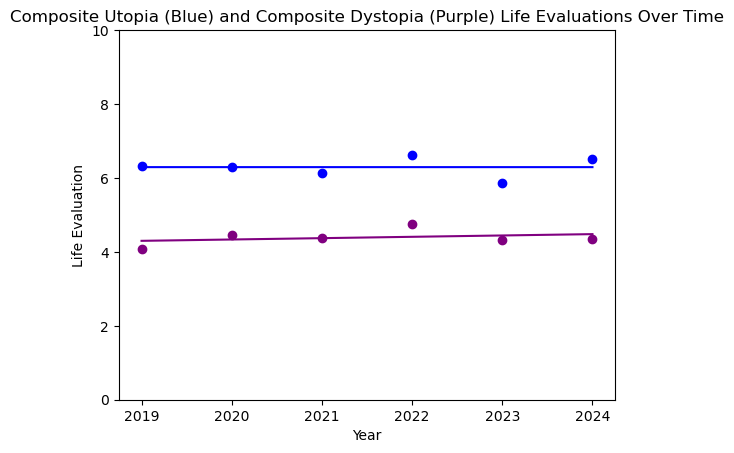

In [73]:
#We can use the standard list format established in the previous block of code in order to call our data and generate a scatter plot
#We reshape the list of years, as it will be our X-axis, and needs to be reshaped to work with regression later
years = np.array([2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
dys_values = np.array(life_eval_means[1:7])
uto_values = np.array(life_eval_means[8:14])

#We will perform linear regression as well, using the Scikit-Learn Module:
#We do this by first generating the linear regression model, and predicting the y values for each x value
#This will let us plot these predicted y values in a moment.
dys_regression = linear_model.LinearRegression()
dys_regression.fit(years, dys_values)
dys_regression_ys = dys_regression.predict(years)

uto_regression = linear_model.LinearRegression()
uto_regression.fit(years, uto_values)
uto_regression_ys = uto_regression.predict(years)

#Now we can make the scatter plots and showcase the linear regression
plt.ylim(0, 10)
plt.title("Composite Utopia (Blue) and Composite Dystopia (Purple) Life Evaluations Over Time")
plt.scatter(years, dys_values, color = 'purple')
plt.scatter(years, uto_values, color = 'blue')
plt.plot(years, dys_regression_ys, color = 'purple')
plt.plot(years, uto_regression_ys, color = 'blue')
plt.xlabel('Year')
plt.ylabel('Life Evaluation')
plt.show()


Interestingly, their pattern tends to be very similar, with life eval jumping for both in 2022, and dipping in 2021 and 2023. The lines created by linear regression are also fascinating, as they are nearly horizontal, suggesting that changes in life evaluation in these composite countries remain roughly the same year to year, despite the countries that contribute to these models changing each year.

Out of curiosity, let's visually examine the difference between the values each year.

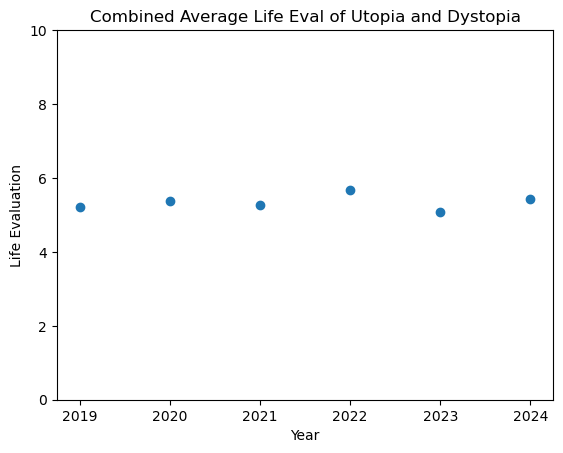

Average of Utopia and Dystopia Life Eval Each Year: [5.212, 5.37955, 5.256066666666666, 5.683366666666666, 5.08935, 5.42755]
Average Life Eval between Countries Comprising Utopia and Dystopia Across All Years: 5.340685714285715


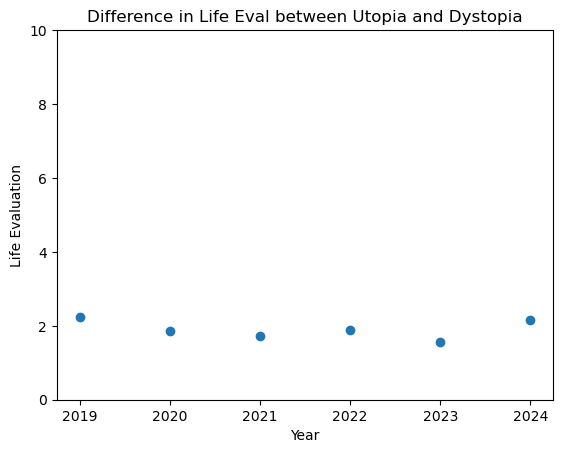

Difference between Utopia and Dystopia Life Eval Each Year: [2.25, 1.8558999999999992, 1.7365333333333322, 1.8779333333333321, 1.5483000000000002, 2.1518999999999986]
Average Difference in Life Eval between Countries Comprising Utopia and Dystopia Across All Years: 1.9021714285714282


In [74]:
#First, we generate the average life evaluations between the two composite countries each year
years = np.array([2019, 2020, 2021, 2022, 2023, 2024])
dys_values = life_eval_means[1:7]
uto_values = life_eval_means[8:14]
avg = [uto_values[0]/2 + dys_values[0]/2, uto_values[1]/2 + dys_values[1]/2, uto_values[2]/2 + dys_values[2]/2, uto_values[3]/2 + dys_values[3]/2, uto_values[4]/2 + dys_values[4]/2, uto_values[5]/2 + dys_values[5]/2]

plt.title("Combined Average Life Eval of Utopia and Dystopia")
plt.ylim(0, 10)
plt.scatter(years, avg)
plt.xlabel('Year')
plt.ylabel('Life Evaluation')
plt.plot()
plt.show()

#We print these data points to provide specific numerical reference as well, and also provide the average value over the years
print("Average of Utopia and Dystopia Life Eval Each Year: " + str(avg))
print("Average Life Eval between Countries Comprising Utopia and Dystopia Across All Years: " + str(life_eval_means[14]/2+life_eval_means[7]/2))

#Next, we generate the difference between the points, to better see the true gap in life eval between the composite countries
diff = [uto_values[0] - dys_values[0], uto_values[1] - dys_values[1], uto_values[2] - dys_values[2], uto_values[3] - dys_values[3], uto_values[4] - dys_values[4], uto_values[5] - dys_values[5]]

plt.title("Difference in Life Eval between Utopia and Dystopia")
plt.ylim(0, 10)
plt.scatter(years, diff)
plt.xlabel('Year')
plt.ylabel('Life Evaluation')
plt.plot()
plt.show()

print("Difference between Utopia and Dystopia Life Eval Each Year: " + str(diff))
print("Average Difference in Life Eval between Countries Comprising Utopia and Dystopia Across All Years: " + str(life_eval_means[14]-life_eval_means[7]))

While examining this over a much longer period would obviously improve the results' reliability, this suggests something fascinating: While the difference in quality of life between the countries that comprise composite dystopia and the countries that comprise composite utopia may be substantial, that difference is relatively constant at about "1.9" points, with the average between them being slightly above "5," the expected "middle" response. This is all despite there being a different set of contributing countries, each with their own changing circumstances, each year. This stability provides some credence as to the value of these composite countries as workable models.

Next, we will shift to analyzing the countries that act as contributors to Dystopia and Utopia geographically by examining them on a map.

In [75]:
#Before we map the countries, I'd like to get dataframes that list of all the countries that ever show up on Utopia list, 
#and all on Dystopia. This will essentially provide me with a record of all the countries I need to look up geo-data for
loc_uto_df = uto_df_total[['Country name']].drop_duplicates().reset_index(drop=True)
loc_dys_df = dys_df_total[['Country name']].drop_duplicates().reset_index(drop=True)
loc_dys_df

,Country name
0,Burundi
1,Central African Republic
2,Afghanistan
3,Greece
4,Bulgaria
5,Chad
6,Croatia
7,Venezuela
8,Lesotho
9,Georgia


I created new CSV files consisting of these contributor countries, and their latitude & longitude (per Google Maps). This file could have been generated using "with open('Composite_Utopia_Country_Coordinates.csv', 'w', newline = '')," but it was much more efficient to create a CSV file via Microsoft Excel, which could then be uploaded to Coursera.

In [76]:
uto_coordinates_df = pd.read_csv('Composite_Utopia_Country_Coordinates.csv')
dys_coordinates_df = pd.read_csv('Composite_Dystopia_Country_Coordinates.csv')
uto_coordinates_df

,Country Name,Latitude,Longitude
0,Luxembourg,49.8153,6.1296
1,Iceland,64.9631,-19.0208
2,Singapore,1.3521,103.8198
3,Uzbekistan,41.3775,64.5853
4,Myanmar,21.9162,95.9560
5,Turkmenistan,38.9697,59.5563
6,Indonesia,-0.7893,113.9213
7,Hong Kong SAR of China,22.3193,114.1694
8,Cambodia,12.5657,104.9910
9,Finland,61.9241,25.7482


Now that we have our location data for each country, we can generate a map and use a function to generate circles at each relevant spot. 

[NOTE TO INSTRUCTOR: The map does not appear to stay generated when saving and forwarding this notebook. You may need to run previous cells as well to ensure it generates. I have also uploaded a screenshot of the generated map as 'Programming for Data Science Summative Assessment 2 Map.png' into the files of this notebook but can also provide it via email or Teams upon request.]

In [77]:
LEEDS_LOC  = ( 53.8008,  -1.5491  )
world_map = Map(basemap=basemaps.OpenTopoMap, center=LEEDS_LOC, zoom=1.5, layout = ipywidgets.Layout(height="700px"))
display(world_map)

def draw_circle( _map, loc, radius = 25000, color = "red", fill_color = None):
    circle = Circle()
    circle.location = loc
    circle.radius = radius
    circle.color = color
    circle.fill_color = fill_color
    _map.add_layer(circle)

#We call the previous function to draw blue circles on Utopia contributing contries, and purple on
#Dystopia contributing countries. These were determined via trial and error for readability based on
#my personal opinions on what colors were easy to see on the map.
for _, vals in uto_coordinates_df.iterrows():
    lat = vals["Latitude"]
    long = vals["Longitude"]
    draw_circle(world_map, (lat,long), color = "blue")
    
for _, vals in dys_coordinates_df.iterrows():
    lat = vals["Latitude"]
    long = vals["Longitude"]
    draw_circle(world_map, (lat,long), color = "purple")
    


Map(center=[53.8008, -1.5491], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

# Project Outcome

## Overview of Results
Overall, I found that the composite Dystopia and composite Utopia tend to be shockingly consistent in their citizens' life evaluations from year to year, despite being comprised of metrics taken from various (and often surprising) sets of countries. Some countries that contribute to Dystopia may have a higher life evaluation than some contributors' to Utopia each year, and vice versa, so this consistency is especially remarkable. The differences in life evaluation are also not as extreme as expected, with each composite being roughly only 1 point away from average in each instance. Geographic clustering also follows unexpected patterns for Utopia contributors, potentially suggesting that there may be aspects of a "Utopia" that go beyond regional trends, and fuels my curiosity to further research "realistic Utopias/Dystopias."

## Objective 1

### Explanation of Results

I aimed to create a subset of the data comprised of the countries that contributed to the WHR's concept of "dystopia," and the equivalent "Utopia" concept. These were created as "dys_df_total" and "uto_df_total" respectively, showing each year's countries that had either "0" scores, or the highest score of the year in any of the categories. A few countries remained consistently present over the years, such as Afghanistan consistently providing a lowest score, and Iceland and Luxembourg each consistently providing a highest score. Some unexpected countries appear within these dataframes, such as Myanmar contributing to "Utopia" in 2019, despite having a lower life evaluation than 2019 "Dystopia" contributors Greece and Bulgaria. 

### Visualisation
For the visualization of this objective, I've provided bar graphs of the Dystopia-contributing (blue) and Utopia-contributing countries (red) for each year. This provides a quick reference as to which countries in a given year contribute one of their statistics, as well as an easy way to compare their life evaluations. 

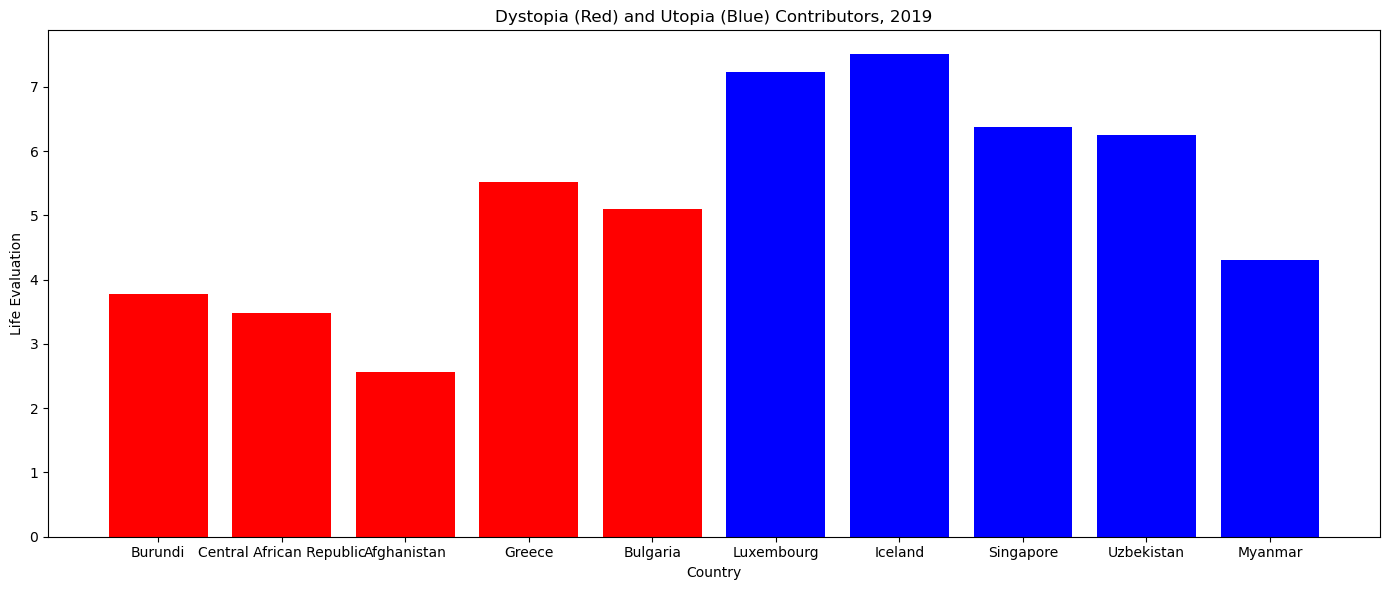

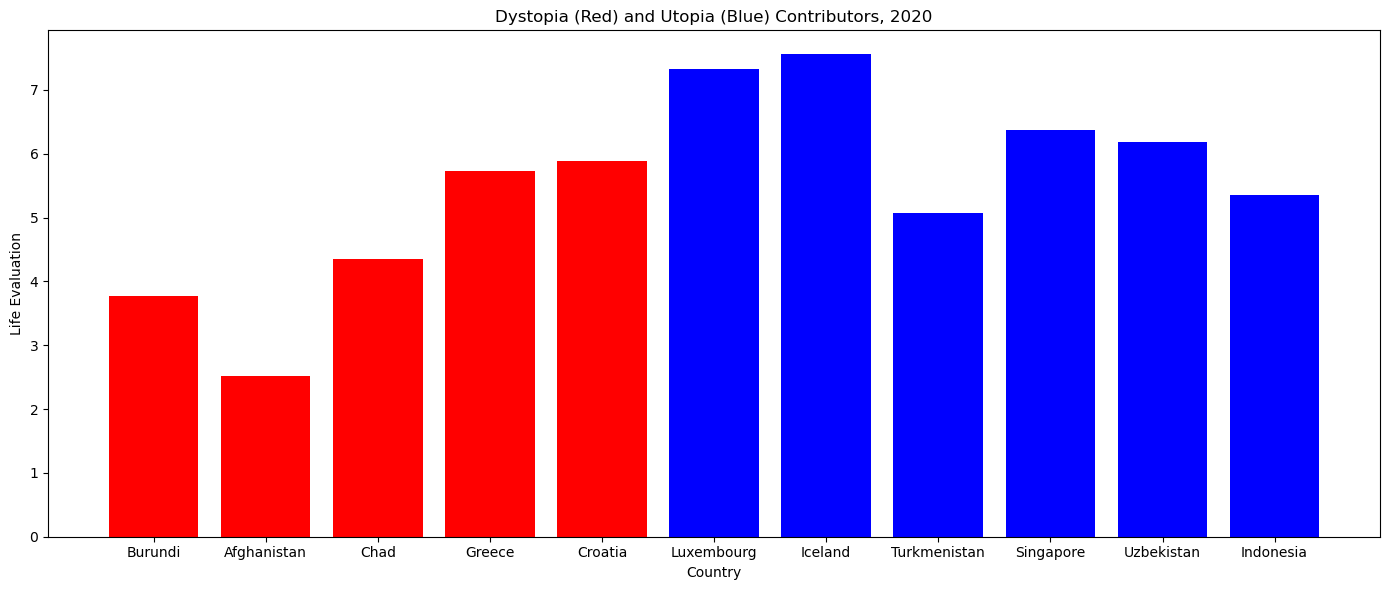

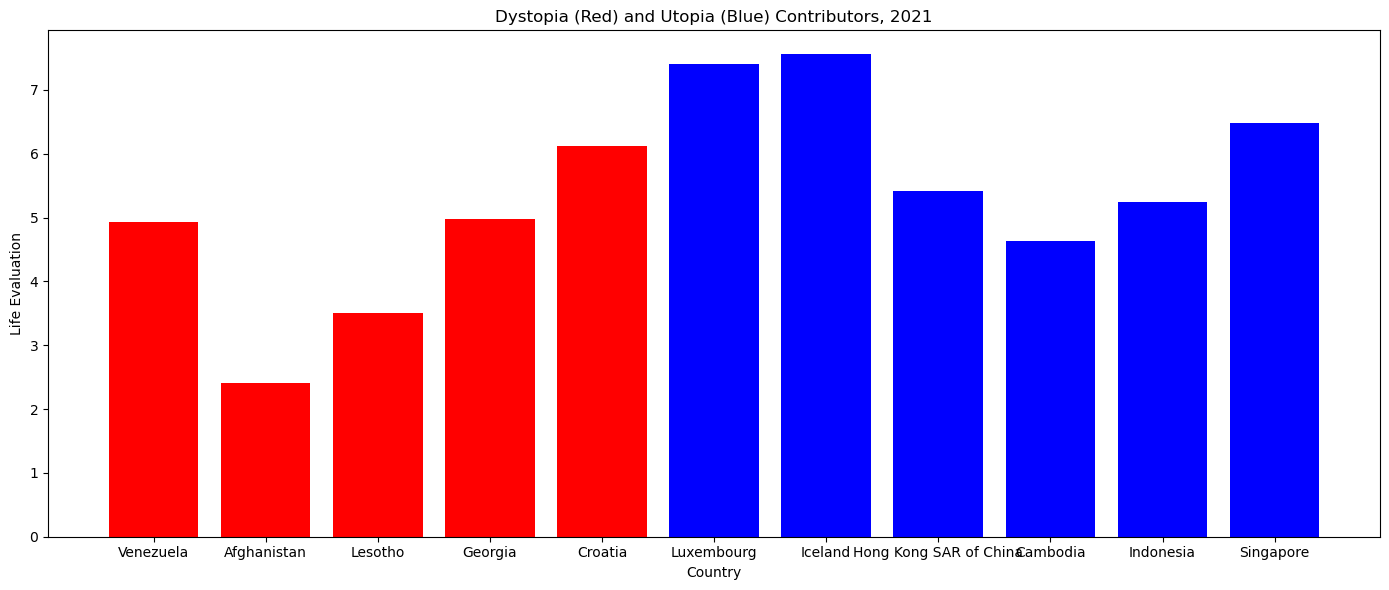

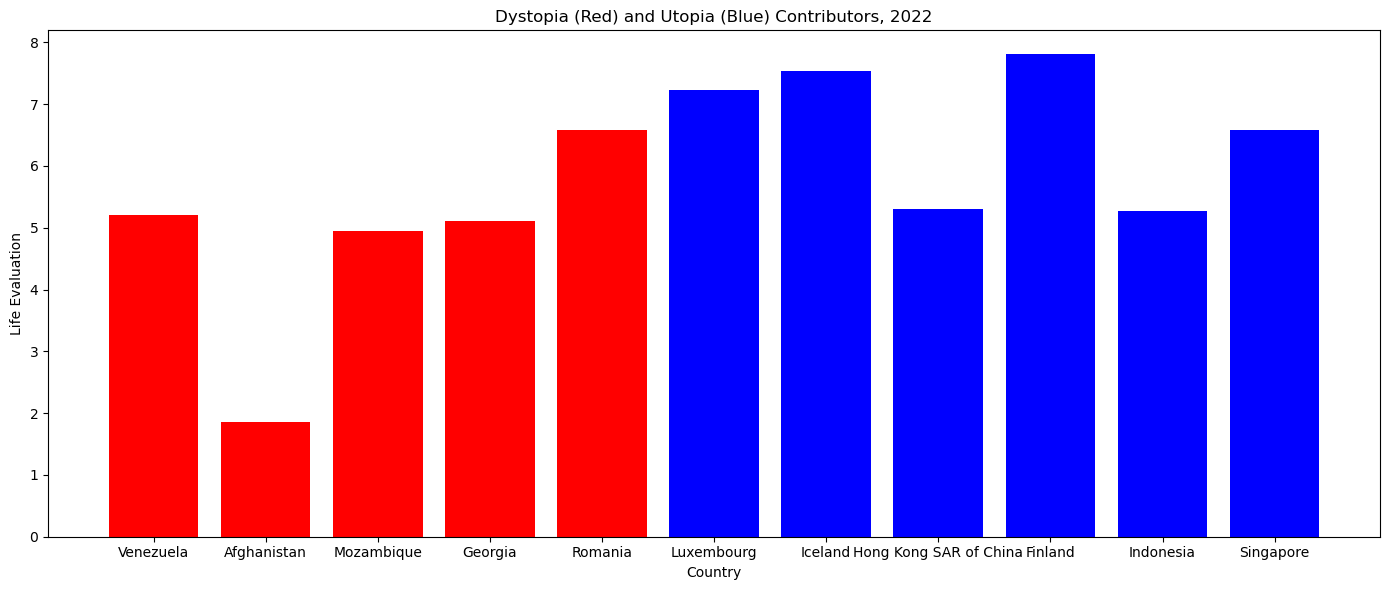

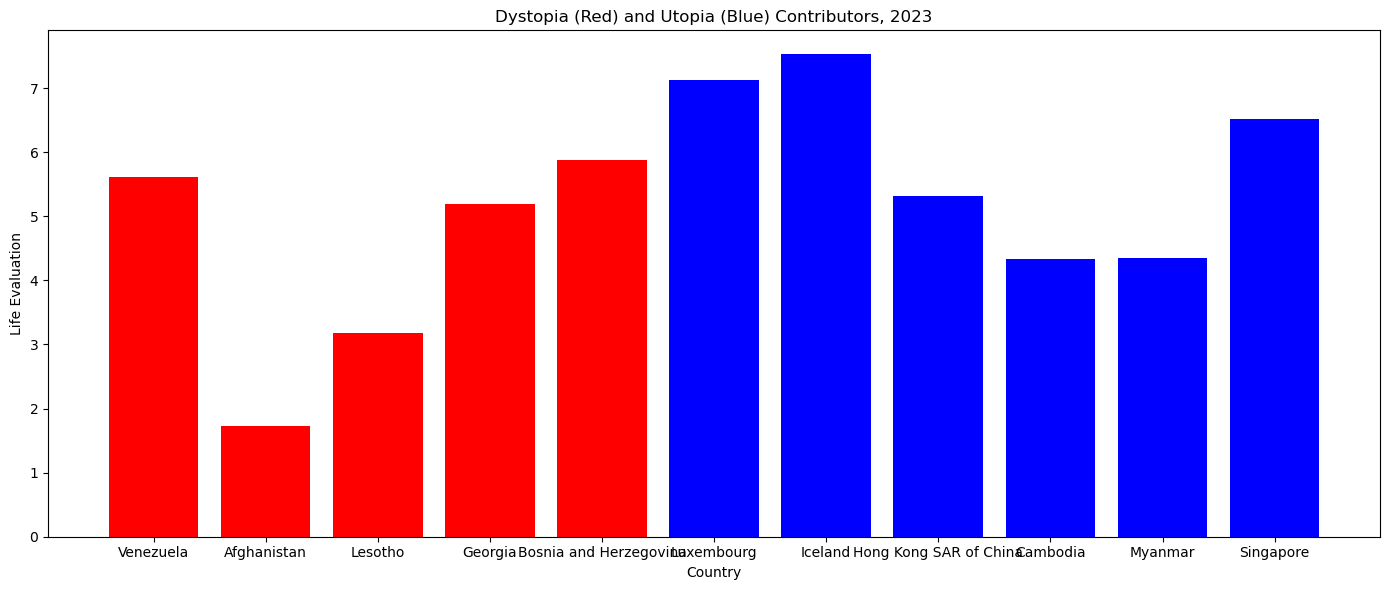

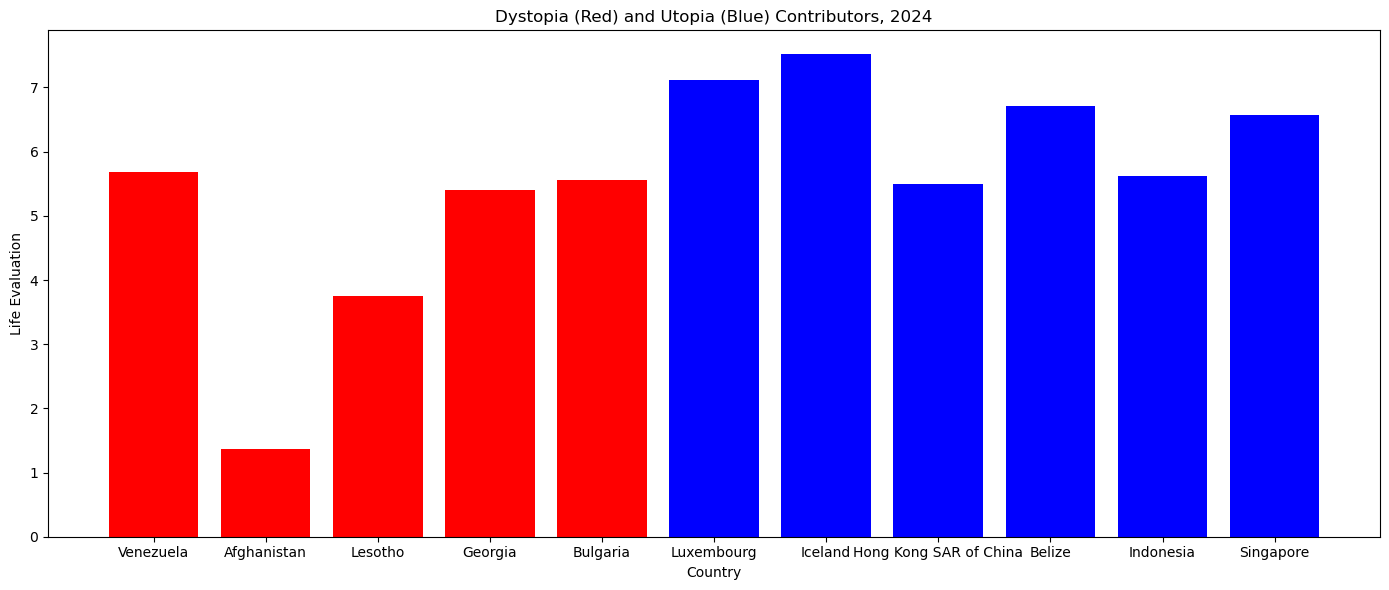

In [78]:
year = 2019
while year <= 2024:
    plt.figure(figsize = (14,6))
    plt.bar(dys_df_total['Country name'].loc[dys_df_total['Year'] == year], dys_df_total['Life evaluation (3-year average)'].loc[dys_df_total['Year'] == year], color = "red")
    plt.bar(uto_df_total['Country name'].loc[uto_df_total['Year'] == year], uto_df_total['Life evaluation (3-year average)'].loc[uto_df_total['Year'] == year], color = "blue")
    plt.title("Dystopia (Red) and Utopia (Blue) Contributors, " + str(year))
    plt.xlabel('Country')
    plt.ylabel('Life Evaluation')
    plt.tight_layout()
    plt.show()
    year += 1


## Objective 2
### Explanation of Results

Next, I sought to draw conclusions about this new "composite dystopia" and "composite utopia", which should better represent what an "average" country with dystopic qualities looks like in reality, as opposed to the "predicted dystopia" estimated by the Wellbeing Research Center. Instead of imagining a country with all the worst (or best, in the case of Utopia) qualities of every contributing country, we averaged the qualities of each contributing country, providing insight as to what realistic "Dystopias" look like in the modern day. 

Interestingly, as easily seen in the following visualization, a person in this "composite dystopia" on average evaluates their life as being above a "4." This is in contrast to the predicted Life Evaluation in a "predicted dystopia," provided at https://www.worldhappiness.report/ed/2025/caring-and-sharing-global-analysis-of-happiness-and-kindness/#happiness-ranking as being estimated at around a "1.37." This suggests that while in our common concept of "dystopia" as the worst imaginable place on Earth misery is a near-constant, in more realistic dystopic circumstances, life evaluations can still often remain closer to a "middling" score. Similarly, Utopian scores were lower than I expected.

That said, the Utopian life evaluation consistently being greater than the Dystopian life evaluation each year by about 2 points, regardless of the countries that contribute to them, does suggest that while deviations in life evaluations may not usually be as extreme  as expected, there is still a major contrast between these two sets of countries.

As seen in the following visualisation, an unusual trend emerged. While more data is needed to be certain, it appears that in general, years in which the average Utopia life evaluation increases correspond to similar increases in the average Dystopia's life evaluation. This may suggest that global factors may play a larger part in impacting the life evaluations of all countries at once than expected, though more research is needed on the subject to be sure.

### Visualisation
While this plot was generated earlier in this report, I believe that it directly assists with understanding my findings, so have provided it again below. The orange represents the average Utopia contributor each year, and the blue represents the average Dystopia contributor each year.

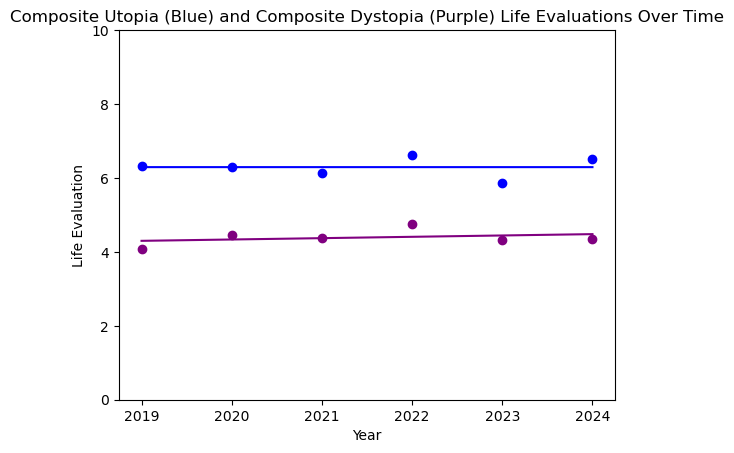

In [80]:
years = np.array([2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
dys_values = np.array(life_eval_means[1:7])
uto_values = np.array(life_eval_means[8:14])

dys_regression = linear_model.LinearRegression()
dys_regression.fit(years, dys_values)
dys_regression_ys = dys_regression.predict(years)

uto_regression = linear_model.LinearRegression()
uto_regression.fit(years, uto_values)
uto_regression_ys = uto_regression.predict(years)

plt.ylim(0, 10)
plt.title("Composite Utopia (Blue) and Composite Dystopia (Purple) Life Evaluations Over Time")
plt.scatter(years, dys_values, color = 'purple')
plt.scatter(years, uto_values, color = 'blue')
plt.plot(years, dys_regression_ys, color = 'purple')
plt.plot(years, uto_regression_ys, color = 'blue')
plt.xlabel('Year')
plt.ylabel('Life Evaluation')
plt.show()

## Objective 3

### Explanation of Results

Finally, I pinpointed every country that appears in any year on either the Utopia-contributing or Dystopia-contributing list on a global map, allowing me to look for geographic trends in the data. A few interesting trends of note were then readily apparent.

First, the locations of data point clusters. With exceptions, Dystopia-contributing countries were clustered primarily in Africa and the Southeastern Europe. In contrast, Utopia-contributing countries were clustered primarily in Southeast Asia, with a few consistently represented countries (namely Iceland and Luxembourg) in Europe. There is always the possibility of cultural bias in polls that elevate European life over life in areas such as Africa that must be acknowledged and examined. But with the available data, I was most fascinated by the appearance of the Southeast Asian Utopian data cluster. While some of these countries may only appear on the list for a single year, countries like Cambodia and Myanmar manage to still possess Utopian qualities, despite having relatively low average life evaluations. I would love to conduct further research, in order to determine a more clear model of "realistic Utopias" - perhaps life evaluation is not the ideal metric for assessment, if countries that do not consistently score highly in that regard are still able to score so highly in other regards. 

Second, the absence of data points in certain locations was interesting. Regularly recognized "world superpowers" such as China, Russia, and the United States did not appear in the list, suggesting that particularly positive life evaluations of citizens may not correspond much with the perceived "power" of a country. Furthermore, there was only 1 Utopian and 1 Dystopian datapoint located in the Americas. This is very interesting as many countries in these regions are often portrayed in Utopian or Dystopian lights, though the data suggests they may not often be examples of either.

### Visualisation
Please refer to the generated world map, located at the end of the "Program Code" portion of this report.

# Conclusion


### Achievements
In this project, I was able to portray new depictions of "dystopia" and "utopia," intended to act as more average depictions of what these concepts look like in reality, as opposed to more hypothetical depictions based on predictive models. I was able to identify patterns in the data provided via the World Happiness Report, indicating relatively consistent trends as to what average life evaluations look like in "composite dystopia" and "composite utopia" each year. I also noticed an inconsistency in the World Happiness Report's depiction of the data, with Indonesia being portrayed as the most generous country of 2019, which the data indicates should be Myanmar. This may be a simple mistake or could be indicative of deeper inconsistencies. Southeast Asia is overall a region that seems to defy some of the assumptions made by the initial project, often having low life evaluations while also contributing to the "composite utopia" model. This could indicate that my model of Utopia needs further refinement, though it could also indicate that the singular "life evaluation" value, determined from a polling question, may not be sufficient in truly determining Happiness and Wellbeing.

### Limitations

This project was limited to using publicly available data provided as part of the World Happiness Report, so direct poll data in its rawest form was not immediately available. All relevant categories of data were also only collected for a time span of 6 years, so to draw more conclusive data, further years of data collection by the project would be desirable.

### Future Work

In future work, I would like to request via the University of Leeds to access the raw data. The discrepancy between what I found to be the most generous country in 2019 and what the World Happiness Report has listed on its website is deeply curious to me, and I believe accessing the raw data could help make the cause of this more apparent. I would also like to more deeply analyze aspects of the countries that compose composite dystopia and utopia that may not have been covered, such as income inequality and various civil rights causes. I believe that it would also be useful to look at alternate methods of determining life evaluation, and alternate ways of then determining which countries possess aspects of dystopia and utopia. It would also be interesting to dig deeper into countries that have high life evaluations but low individual factors, or the opposite. Further research into various countries, especially in Southeast Asia, may help provide better insights, and may possibly lead to a better model for happiness than the current one - though that is speculation. Altogether, I believe that this is only the tip of the iceberg on this subject, and there is great potential in better understanding how life is experienced around the world, and how a country's way of being impacts its populace.

# References:

All data received from the World Happiness Report and Google Maps (Other data sets were uploaded to this Coursera Lab before I identified them as secondary sources, and were not used in the construction of this project):

* Helliwell, J. F., Layard, R., Sachs, J. D., De Neve, J.-E., Aknin, L. B., & Wang, S. (Eds.). (2024). World Happiness Report 2024. University of Oxford: Wellbeing Research Centre.

* Google. (n.d.-a). Google maps. https://maps.google.com/ 

The following sources (and AI tool) were used as references for programming syntax in a learning context, but not for performing any data analysis:
* Google Copilot; (Used for various quick references of Python Syntax)
* https://scikit-learn.org/stable/modules/linear_model.html (Used to learn about Scikit-learn, especially in regards to running linear regression)
* https://www.w3schools.com/python/matplotlib_labels.asp (Used to further learn more in depth methods of generating and labelling plots)
* https://stackoverflow.com/questions/67306234/resetting-index-after-removing-rows-from-pandas-data-frame; (Used to learn how to reset indexing in DataFrames)
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html (Used to learn techniques to condense data, eliminating duplicate rows when necessary)
* OMAT5100M Programming for Data Science
